# **Thông tin nhóm**
- Lớp: ML 23KHDL1
- Nhóm: 6
- Sinh viên: 
    - 23127102 - Lê Quang Phúc
    - 23127212 - Nguyễn Quang Đăng Khoa
    - 23127241 - Đoàn Thành Phát
    - 23127332 - Trần Tiến Cường
    - 23127442 - Trầm Hữu Nhân


# **Tiền xử lý và khám phá dữ liệu**
## Bộ dữ liệu Vietnamese OCR 
Notebook này thực hiện:
1. Định nghĩa, xử lý dường dẫn, cấu trúc data mà Nhóm lưu trữ
2. Tiền xử lý dữ liệu
3. Khám phá dữ liệu
4. Tạo Data folder - dùng cho các bước tiếp theo

## 1. Thư viện

In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import shutil
import zipfile
import matplotlib.font_manager as fm
import re
import random

from pathlib import Path
from collections import Counter
from PIL import Image
from google.colab import drive
from tqdm import tqdm
from wordcloud import WordCloud

!apt-get -qq install fonts-dejavu

# Cấu hình cho matplotlib
mpl.rcParams['font.family'] = 'DejaVu Sans'
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Mount tới Google Drive của nhóm
drive.mount('/content/drive')

Selecting previously unselected package fonts-dejavu-core.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../fonts-dejavu-core_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-core (2.37-2build1) ...
Selecting previously unselected package fonts-dejavu-extra.
Preparing to unpack .../fonts-dejavu-extra_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-extra (2.37-2build1) ...
Selecting previously unselected package fonts-dejavu.
Preparing to unpack .../fonts-dejavu_2.37-2build1_all.deb ...
Unpacking fonts-dejavu (2.37-2build1) ...
Setting up fonts-dejavu-core (2.37-2build1) ...
Setting up fonts-dejavu-extra (2.37-2build1) ...
Setting up fonts-dejavu (2.37-2build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


## 2. Các bước thực hiện

### 2.1 Unzip dữ liệu

Note: Thực hiện thêm đối với bộ dữ liệu nhóm chuẩn bị

In [ ]:
!unzip -q "/content/drive/MyDrive/IntroToML - OCR/UIT_HWDB_word.zip" -d "/content/local_data"
!unzip -q "/content/drive/MyDrive/IntroToML - OCR/UIT_HWDB_line.zip" -d "/content/local_data"
!unzip -q "/content/drive/MyDrive/IntroToML - OCR/UIT_HWDB_paragraph.zip" -d "/content/local_data"

### 2.2 Xử lý dữ liệu thiếu

Note: 
- Xử lý thêm dữ liệu của nhóm chuẩn bị
- Mô tả mã nguồn bên cell dưới làm gì (viết theo dạng pipeline thực hiện, không cần liệt kê chi tiết kỹ thuật, mã nguồn thực hiện)
- Clean này là "làm sạch" dữ liệu hay là dữ liệu "sạch" -> cân nhắc đặt lại tên để tránh gây nhầm lẫn (t thấy markdown cũ ghi là xử lý dữ liệu thiếu)

In [ ]:
def strict_cleanup_folders(base_path):
    base_path = Path(base_path)
    deleted_count = 0
    total_folders = 0

    if not base_path.exists():
        print(f"Đường dẫn không tồn tại: {base_path}")
        return

    # Duyệt qua các thư mục con
    for folder in base_path.iterdir():
        if folder.is_dir():
            total_folders += 1
            label_file = folder / 'label.json'

            # Kiểm tra sự tồn tại của file label.json
            if not label_file.exists():
                print(f"Thiếu label.json tại: {folder.name}")
                shutil.rmtree(folder)
                deleted_count += 1
                continue

            try:
                # Đọc label.json
                with open(label_file, 'r', encoding='utf-8') as f:
                    labels = json.load(f)

                # Danh sách tên file ảnh thực tế trong folder
                actual_images = {f.name for f in folder.glob('*.jpg')}
                # Danh sách tên file ảnh được liệt kê trong label.json
                labeled_images = set(labels.keys())

                is_valid = True

                # Điều kiện 1: Có ảnh thực tế nhưng không có trong label
                extra_images = actual_images - labeled_images
                if extra_images:
                    print(f"[XÓA] {folder.name}: Có ảnh {list(extra_images)[:3]}... nhưng không có label.")
                    is_valid = False

                # Điều kiện 2: Có label nhưng không tìm thấy file ảnh tương ứng
                if is_valid:
                    missing_images = labeled_images - actual_images
                    if missing_images:
                        print(f"[XÓA] {folder.name}: Có label cho {list(missing_images)[:3]}... nhưng thiếu file ảnh.")
                        is_valid = False

                # Thực hiện xóa nếu vi phạm một trong hai điều kiện
                if not is_valid:
                    shutil.rmtree(folder)
                    deleted_count += 1

            except Exception as e:
                print(f"Không thể xử lý {folder.name}: {e}")

    print("-" * 30)
    print(f"KẾT QUẢ DỌN DẸP:")
    print(f"- Tổng số folder đã quét: {total_folders}")
    print(f"- Số folder bị xóa: {deleted_count}")
    print(f"- Số folder hợp lệ còn lại: {total_folders - deleted_count}")

# Gọi hàm
DATA_PATH = ["/content/local_data/UIT_HWDB_word/train_data", "/content/local_data/UIT_HWDB_word/test_data", "/content/local_data/UIT_HWDB_line/test_data", "/content/local_data/UIT_HWDB_line/train_data", "/content/local_data/UIT_HWDB_paragraph/test_data", "/content/local_data/UIT_HWDB_paragraph/train_data"]

for path in DATA_PATH:
  strict_cleanup_folders(path)


### 2.3 Lưu dữ liệu 

Note:
- Xử lý thêm dữ liệu của nhóm chuẩn bị 
- Mô tả mã nguồn bên cell dưới

In [ ]:
# Đường dẫn
LOCAL_DATA_DIR = Path("/content/local_data")
DRIVE_DIR = Path("/content/drive/MyDrive/IntroToML - OCR")
OUTPUT_ZIP = DRIVE_DIR / "UIT_Cleaned.zip"
TEMP_CLEANED_DIR = Path("/content/UIT_Cleaned")

# Tạo thư mục tạm với cấu trúc yêu cầu
os.makedirs(TEMP_CLEANED_DIR, exist_ok=True)

# Định nghĩa mapping từ source sang destination
SOURCE_DEST_MAPPING = [
    (LOCAL_DATA_DIR / "UIT_HWDB_line", TEMP_CLEANED_DIR / "UIT_HWDB_line"),
    (LOCAL_DATA_DIR / "UIT_HWDB_paragraph", TEMP_CLEANED_DIR / "UIT_HWDB_paragraph"),
    (LOCAL_DATA_DIR / "UIT_HWDB_word", TEMP_CLEANED_DIR / "UIT_HWDB_word"),
]

# Copy dữ liệu với xử lý encoding tiếng Việt
for src, dst in SOURCE_DEST_MAPPING:
    if src.exists():
        print(f"  - Copy {src.name} -> {dst.name}")

        # Tạo thư mục đích
        os.makedirs(dst, exist_ok=True)

        # Duyệt qua các thư mục con 
        for folder in tqdm(list(src.iterdir()), desc=f"    Processing {src.name}"):
            if folder.is_dir():
                dst_folder = dst / folder.name
                shutil.copytree(folder, dst_folder, dirs_exist_ok=True)

                # Kiểm tra và xử lý encoding cho label.json nếu cần
                label_file = dst_folder / "label.json"
                if label_file.exists():
                    try:
                        # Đọc và ghi lại với encoding UTF-8 để đảm bảo
                        with open(label_file, 'r', encoding='utf-8') as f:
                            labels = json.load(f)
                        with open(label_file, 'w', encoding='utf-8') as f:
                            json.dump(labels, f, ensure_ascii=False, indent=2)
                    except Exception as e:
                        print(f"Lỗi xử lý {label_file}: {e}")
    else:
        print(f"Không tìm thấy: {src}")

# Tạo file ZIP
print("\nĐang nén thành UIT_Cleaned.zip...")

def zip_with_utf8(zip_path, folder_to_zip):
    """Nén folder với hỗ trợ UTF-8 cho tên file tiếng Việt"""
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_to_zip):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(folder_to_zip))
                try:
                    # Đảm bảo tên file trong zip được encode UTF-8
                    zipf.write(file_path, arcname)
                except Exception as e:
                    print(f"Lỗi nén {file}: {e}")

zip_with_utf8(OUTPUT_ZIP, TEMP_CLEANED_DIR)

# Kiểm tra kết quả
print(f"\nĐã tạo file: {OUTPUT_ZIP}")
file_size = os.path.getsize(OUTPUT_ZIP) / (1024 * 1024)
print(f"Kích thước: {file_size:.2f} MB")

# Xóa thư mục tạm
shutil.rmtree(TEMP_CLEANED_DIR)

Tạo cấu trúc thư mục tạm...
Copy dữ liệu vào thư mục tạm...
  - Copy UIT_HWDB_line -> UIT_HWDB_line


    Processing UIT_HWDB_line: 100%|██████████| 2/2 [00:11<00:00,  5.76s/it]


  - Copy UIT_HWDB_paragraph -> UIT_HWDB_paragraph


    Processing UIT_HWDB_paragraph: 100%|██████████| 2/2 [00:01<00:00,  1.09it/s]


  - Copy UIT_HWDB_word -> UIT_HWDB_word


    Processing UIT_HWDB_word: 100%|██████████| 2/2 [00:32<00:00, 16.38s/it]



Đang nén thành UIT_Cleaned.zip...

Đã tạo file: /content/drive/MyDrive/IntroToML - OCR/UIT_Cleaned.zip
Kích thước: 1858.86 MB

Dọn dẹp thư mục tạm...

Hoàn thành! Hãy tải file UIT_Cleaned.zip về máy và kiểm tra cấu trúc.


### 2.4 Thống kê về dữ liệu

#### 2.4.1 [Tên mục]

Note:
- Xử lý thêm dữ liệu của nhóm
- Mô tả cell bên dưới

In [ ]:
# Cấu hình font cho tiếng Việt
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

# Đường dẫn đến dữ liệu đã cleaned
CLEANED_DATA_DIR = Path("/content/local_data")
DATASET_TYPES = ['UIT_HWDB_line', 'UIT_HWDB_paragraph', 'UIT_HWDB_word']
DATA_SPLITS = ['train_data', 'test_data']

def collect_dataset_info(data_dir, dataset_name):
    info = {
        'dataset': dataset_name,
        'total_images': 0,
        'total_labels': 0,
        'total_characters': 0,
        'total_words': 0,
        'unique_labels': set(),
        'image_extensions': Counter(),
        'char_counter': Counter(),
        'word_counter': Counter(),
        'samples': [],
        'train_count': 0,
        'test_count': 0,
        'folder_stats': [],
        'image_resolutions': [],
        'text_lengths': [],
        'word_counts': []
    }

    for split in DATA_SPLITS:
        split_path = data_dir / split
        if not split_path.exists():
            continue

        for num_folder in split_path.iterdir():
            if not num_folder.is_dir():
                continue

            label_file = num_folder / 'label.json'
            if not label_file.exists():
                continue

            try:
                with open(label_file, 'r', encoding='utf-8') as f:
                    labels = json.load(f)

                images = list(num_folder.glob('*.jpg')) + list(num_folder.glob('*.png'))

                folder_stat = {
                    'folder_name': num_folder.name,
                    'split': split,
                    'num_images': len(images),
                    'num_labels': len(labels),
                    'total_chars': sum(len(label) for label in labels.values()),
                    'total_words': sum(len(label.split()) for label in labels.values()),
                    'avg_chars': np.mean([len(label) for label in labels.values()]) if labels else 0,
                    'avg_words': np.mean([len(label.split()) for label in labels.values()]) if labels else 0
                }
                info['folder_stats'].append(folder_stat)

                info['total_images'] += len(images)
                info['total_labels'] += len(labels)

                if 'train' in split:
                    info['train_count'] += len(images)
                else:
                    info['test_count'] += len(images)

                info['unique_labels'].update(labels.values())

                for label in labels.values():
                    text_length = len(label)
                    word_count = len(label.split())

                    info['total_characters'] += text_length
                    info['total_words'] += word_count
                    info['text_lengths'].append(text_length)
                    info['word_counts'].append(word_count)

                    info['char_counter'].update(label.lower())
                    info['word_counter'].update(label.split())

                    if len(info['samples']) < 50:
                        first_image = list(labels.keys())[0] if labels else None
                        info['samples'].append({
                            'folder': num_folder.name,
                            'split': split,
                            'image': first_image,
                            'label': label[:100] + '...' if len(label) > 100 else label,
                            'length': text_length,
                            'words': word_count
                        })

                for img in images:
                    ext = img.suffix.lower()
                    info['image_extensions'][ext] += 1

                    try:
                        with Image.open(img) as img_pil:
                            width, height = img_pil.size
                            info['image_resolutions'].append({
                                'file': img.name,
                                'folder': num_folder.name,
                                'split': split,
                                'width': width,
                                'height': height,
                                'aspect_ratio': width/height if height > 0 else 0,
                                'format': img_pil.format,
                                'mode': img_pil.mode,
                                'size_kb': os.path.getsize(img) / 1024
                            })
                    except Exception as e:
                        pass

            except Exception as e:
                print(f"      Lỗi xử lý {num_folder.name}: {e}")

    return info

all_info = []
for dataset in DATASET_TYPES:
    dataset_path = CLEANED_DATA_DIR / dataset
    if dataset_path.exists():
        print(f"\nĐang xử lý: {dataset}")
        info = collect_dataset_info(dataset_path, dataset)
        if info['total_images'] > 0:
            all_info.append(info)
            print(f"   Tìm thấy: {info['total_images']:,} ảnh, {info['total_labels']:,} labels")
            print(f"      Train: {info['train_count']:,} | Test: {info['test_count']:,}")
        else:
            print(f"   Không tìm thấy dữ liệu trong {dataset}")



Đang xử lý: UIT_HWDB_line
   Tìm thấy: 7,228 ảnh, 7,228 labels
      Train: 7,027 | Test: 201

Đang xử lý: UIT_HWDB_paragraph
   Tìm thấy: 1,144 ảnh, 1,144 labels
      Train: 1,113 | Test: 31

Đang xử lý: UIT_HWDB_word
   Tìm thấy: 110,483 ảnh, 110,483 labels
      Train: 107,602 | Test: 2,881


#### 2.4.2 Tổng quan về bộ dữ liệu

Note: 
- Xử lý thêm dữ liệu của nhóm

In [ ]:
total_images = sum(info['total_images'] for info in all_info)
total_labels = sum(info['total_labels'] for info in all_info)
total_chars = sum(info['total_characters'] for info in all_info)
total_words = sum(info['total_words'] for info in all_info)
unique_labels = set()
for info in all_info:
    unique_labels.update(info['unique_labels'])

print(f"\nTHỐNG KÊ TỔNG THỂ:")
print(f"   - Tổng số ảnh: {total_images:,}")
print(f"   - Tổng số labels: {total_labels:,}")
print(f"   - Số labels unique: {len(unique_labels):,}")
print(f"   - Tổng số ký tự: {total_chars:,}")
print(f"   - Tổng số từ: {total_words:,}")

print(f"\nCHI TIẾT THEO LOẠI DỮ LIỆU:")
for info in all_info:
    print(f"\n   {info['dataset']}:")
    print(f"      - Số ảnh: {info['total_images']:,} (Train: {info['train_count']:,} | Test: {info['test_count']:,})")
    print(f"      - Số labels: {info['total_labels']:,}")
    print(f"      - Số ký tự: {info['total_characters']:,}")
    print(f"      - Số từ: {info['total_words']:,}")
    print(f"      - Độ dài label trung bình: {info['total_characters']/info['total_labels']:.1f} ký tự")
    print(f"      - Số từ trung bình: {info['total_words']/info['total_labels']:.1f} từ")


THỐNG KÊ TỔNG THỂ:
   - Tổng số ảnh: 118,855
   - Tổng số labels: 118,855
   - Số labels unique: 10,463
   - Tổng số ký tự: 1,356,762
   - Tổng số từ: 338,354

CHI TIẾT THEO LOẠI DỮ LIỆU:

   UIT_HWDB_line:
      - Số ảnh: 7,228 (Train: 7,027 | Test: 201)
      - Số labels: 7,228
      - Số ký tự: 489,608
      - Số từ: 113,490
      - Độ dài label TB: 67.7 ky tu
      - Số từ TB: 15.7 tu

   UIT_HWDB_paragraph:
      - Số ảnh: 1,144 (Train: 1,113 | Test: 31)
      - Số labels: 1,144
      - Số ký tự: 499,563
      - Số từ: 114,381
      - Độ dài label TB: 436.7 ky tu
      - Số từ TB: 100.0 tu

   UIT_HWDB_word:
      - Số ảnh: 110,483 (Train: 107,602 | Test: 2,881)
      - Số labels: 110,483
      - Số ký tự: 367,591
      - Số từ: 110,483
      - Độ dài label TB: 3.3 ky tu
      - Số từ TB: 1.0 tu


#### 2.4.3 Phân tích ký tự tiếng Việt

In [11]:
VIETNAMESE_CHARS = {
    'lowercase': 'àáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵđ',
    'uppercase': 'ÀÁẢÃẠĂẰẮẲẴẶÂẦẤẨẪẬÈÉẺẼẸÊỀẾỂỄỆÌÍỈĨỊÒÓỎÕỌÔỒỐỔỖỘƠỜỚỞỠỢÙÚỦŨỤƯỪỨỬỮỰỲÝỶỸỴĐ',
}

all_chars_counter = Counter()
for info in all_info:
    all_chars_counter.update(info['char_counter'])

vn_chars = VIETNAMESE_CHARS['lowercase'] + VIETNAMESE_CHARS['uppercase']
vn_char_count = sum(count for char, count in all_chars_counter.items() if char in vn_chars)
total_char_count = sum(all_chars_counter.values())

print(f"\nTHỐNG KÊ KÝ TỰ:")
print(f"   - Tổng số ký tự: {total_char_count:,}")
print(f"   - Số ký tự unique: {len(all_chars_counter):,}")
print(f"   - Ký tự có dấu tiếng Việt: {vn_char_count:,} ({vn_char_count/total_char_count*100:.2f}%)")

print(f"\nTOP 10 KÝ TỰ PHỔ BIẾN NHẤT:")
top_chars = all_chars_counter.most_common(10)
for i, (char, count) in enumerate(top_chars, 1):
    display_char = "' '" if char == ' ' else f"'{char}'"
    percentage = count/total_char_count*100
    print(f"   {i:2d}. {display_char:10s}: {count:8,d} ({percentage:5.2f}%)")

vn_only_counter = Counter({char: count for char, count in all_chars_counter.items() if char in vn_chars})
if vn_only_counter:
    print(f"\nTOP 10 KÝ TỰ TIẾNG VIỆT PHỔ BIẾN NHẤT:")
    top_vn_chars = vn_only_counter.most_common(10)
    for i, (char, count) in enumerate(top_vn_chars, 1):
        percentage = count/vn_char_count*100
        print(f"   {i:2d}. '{char}': {count:7,d} ({percentage:5.2f}%)")


THỐNG KÊ KÝ TỰ:
   - Tổng số ký tự: 1,356,762
   - Số ký tự unique: 118
   - Ký tự có dấu tiếng Việt: 321,627 (23.71%)

TOP 10 KÝ TỰ PHỔ BIẾN NHẤT:
    1. ' '       :  219,499 (16.18%)
    2. 'n'       :  136,087 (10.03%)
    3. 'h'       :   97,393 ( 7.18%)
    4. 't'       :   71,467 ( 5.27%)
    5. 'c'       :   67,633 ( 4.98%)
    6. 'g'       :   63,149 ( 4.65%)
    7. 'i'       :   63,146 ( 4.65%)
    8. 'đ'       :   31,004 ( 2.29%)
    9. 'a'       :   30,560 ( 2.25%)
   10. 'u'       :   30,136 ( 2.22%)

TOP 10 KÝ TỰ TIẾNG VIỆT PHỔ BIẾN NHẤT:
    1. 'đ':  31,004 ( 9.64%)
    2. 'à':  24,064 ( 7.48%)
    3. 'ư':  20,333 ( 6.32%)
    4. 'á':  15,058 ( 4.68%)
    5. 'ô':  13,082 ( 4.07%)
    6. 'ế':   9,777 ( 3.04%)
    7. 'ó':   9,029 ( 2.81%)
    8. 'ạ':   8,903 ( 2.77%)
    9. 'ả':   8,702 ( 2.71%)
   10. 'ộ':   8,578 ( 2.67%)


#### 2.4.4 Phân tích từ vựng

In [12]:
all_words_counter = Counter()
for info in all_info:
    all_words_counter.update(info['word_counter'])

print(f"\nTHỐNG KÊ TỪ VỰNG:")
print(f"   - Tổng số từ: {total_words:,}")
print(f"   - Số từ unique: {len(all_words_counter):,}")
print(f"   - Từ xuất hiện 1 lần: {sum(1 for count in all_words_counter.values() if count == 1):,}")

print(f"\nTOP 10 TỪ PHỔ BIẾN NHẤT:")
top_words = all_words_counter.most_common(10)
for i, (word, count) in enumerate(top_words, 1):
    print(f"   {i:2d}. '{word}': {count:6,d} lần")


THỐNG KÊ TỪ VỰNG:
   - Tổng số từ: 338,354
   - Số từ unique: 5,665
   - Từ xuất hiện 1 lần: 106

TOP 10 TỪ PHỔ BIẾN NHẤT:
    1. 'có':  3,584 lần
    2. 'là':  3,367 lần
    3. 'và':  3,325 lần
    4. 'người':  2,938 lần
    5. 'của':  2,920 lần
    6. 'một':  2,688 lần
    7. '"':  2,662 lần
    8. 'không':  2,638 lần
    9. 'được':  2,446 lần
   10. 'đã':  2,363 lần


#### 2.4.5 Phân tích độ phân giải ảnh

In [13]:
all_resolutions = []
for info in all_info:
    all_resolutions.extend(info['image_resolutions'])

if all_resolutions:
    df_res = pd.DataFrame(all_resolutions)
    print(f"\nTHỐNG KÊ KÍCH THƯỚC:")
    print(f"   - Chiều rộng: Min: {df_res['width'].min():.0f}px, Max: {df_res['width'].max():.0f}px, TB: {df_res['width'].mean():.0f}px")
    print(f"   - Chiều cao: Min: {df_res['height'].min():.0f}px, Max: {df_res['height'].max():.0f}px, TB: {df_res['height'].mean():.0f}px")
    print(f"   - Aspect ratio: Min: {df_res['aspect_ratio'].min():.2f}, Max: {df_res['aspect_ratio'].max():.2f}, TB: {df_res['aspect_ratio'].mean():.2f}")
    print(f"   - Dung lượng file: Min: {df_res['size_kb'].min():.1f}KB, Max: {df_res['size_kb'].max():.1f}KB, TB: {df_res['size_kb'].mean():.1f}KB")


THỐNG KÊ KÍCH THƯỚC:
   - Chiều rộng: Min: 128px, Max: 2048px, TB: 263px
   - Chiều cao: Min: 23px, Max: 2290px, TB: 108px
   - Aspect ratio: Min: 0.13, Max: 28.44, TB: 2.16
   - Dung lượng file: Min: 1.7KB, Max: 1718.4KB, TB: 15.9KB


### 2.5 Trực quan hóa dữ liệu

Note: 
- Giảm size của các chart đơn (6, 4)
- Đồng bộ chung về size, font chữ title, legend, màu, các axis,... cho TẤT CẢ các chart bên dưới (tham khảo các nguyên tắc về Visual Encoding, Perceptron, và Color Theory)
- Nên chuyển về vẽ chart theo plotly (ảnh động) nó sẽ đẹp hơn và tăng tính tương tác đối với biểu đồ (làm cuối cùng để đảm bảo thời gian)
- 

#### 2.5.1 Số lượng ảnh từng loại

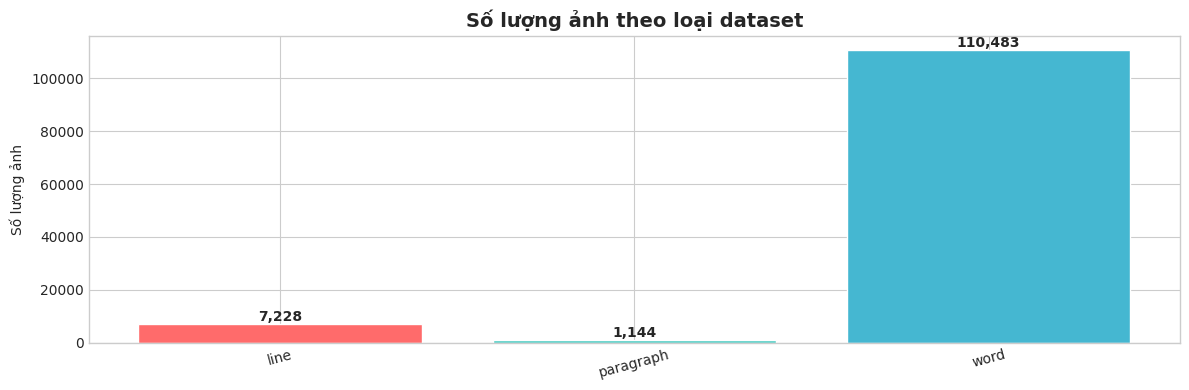

In [14]:
plt.figure(figsize=(12, 4))
datasets = [info['dataset'].replace('UIT_HWDB_', '') for info in all_info]
image_counts = [info['total_images'] for info in all_info]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = plt.bar(datasets, image_counts, color=colors)
plt.title('Số lượng ảnh theo loại dataset', fontsize=14, fontweight='bold')
plt.ylabel('Số lượng ảnh')
plt.xticks(rotation=15)

for bar, count in zip(bars, image_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

Nhận xét: 


#### 2.5.2 Phân bố độ dài theo file .json

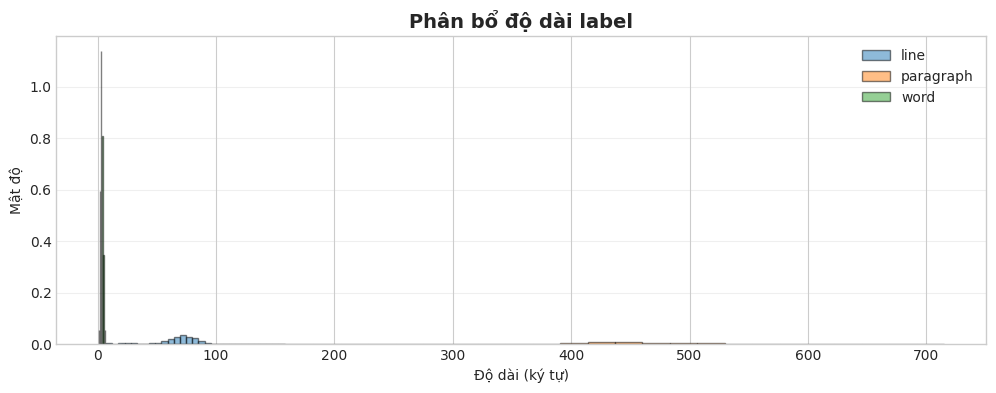

In [15]:
plt.figure(figsize=(12, 4))
for info in all_info:
    if info['text_lengths']:
        plt.hist(info['text_lengths'], alpha=0.5, label=info['dataset'].replace('UIT_HWDB_', ''),
                 bins=30, density=True, edgecolor='black')
plt.title('Phân bổ độ dài label', fontsize=14, fontweight='bold')
plt.xlabel('Độ dài (ký tự)')
plt.ylabel('Mật độ')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Nhận xét: 

#### 2.5.3 Tỉ lệ kí tự có dấu mỗi loại

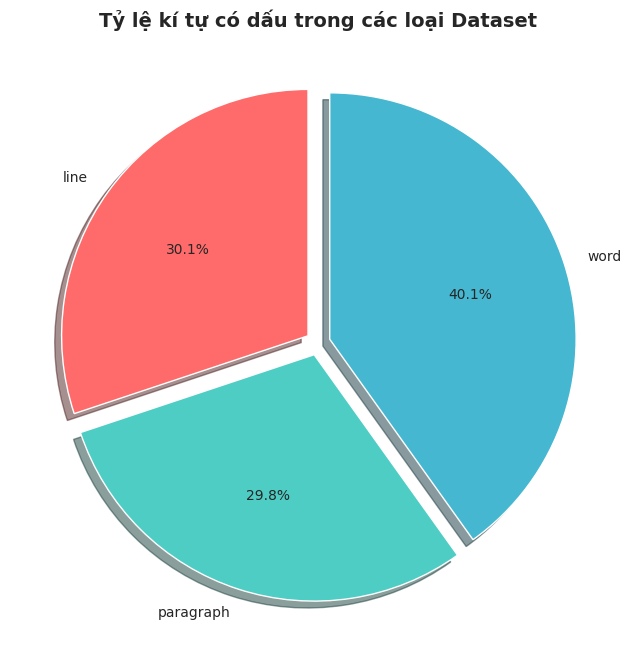

In [16]:
plt.figure(figsize=(12, 8))
vn_ratios = []
for info in all_info:
    vn_count = sum(count for char, count in info['char_counter'].items() if char in vn_chars)
    total = sum(info['char_counter'].values())
    vn_ratios.append(vn_count/total*100 if total > 0 else 0)

plt.pie(vn_ratios, labels=datasets, autopct='%1.1f%%', colors=colors, startangle=90,
        explode=[0.05]*len(vn_ratios), shadow=True)
plt.title('Tỷ lệ kí tự có dấu trong các loại Dataset', fontsize=14, fontweight='bold')
plt.show()

Nhận xét:

#### 2.5.4 Phân tích ký tự

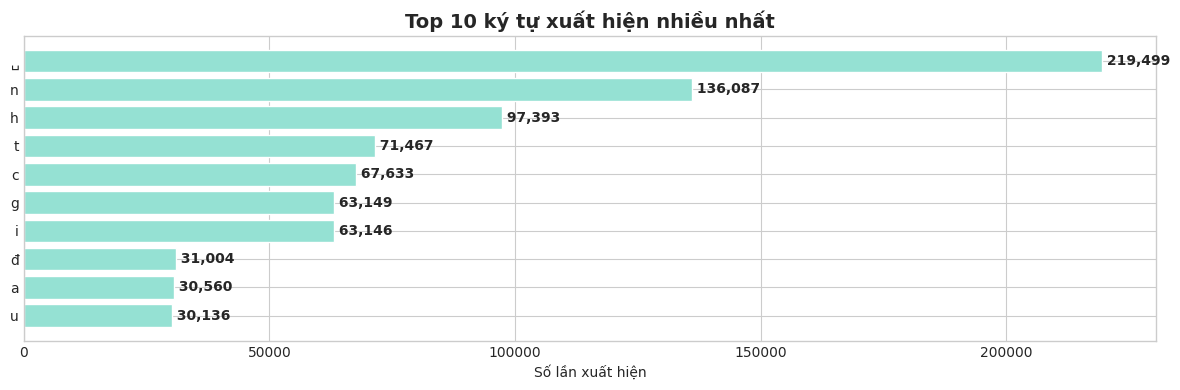

In [17]:
plt.figure(figsize=(12, 4))
top_10_chars = all_chars_counter.most_common(10)
chars = [c[0] if c[0] != ' ' else '␣' for c in top_10_chars]
counts = [c[1] for c in top_10_chars]

bars = plt.barh(chars, counts, color='#95E1D3')
plt.gca().invert_yaxis() # Đảo ngược để ký tự nhiều nhất nằm trên cùng
plt.title('Top 10 ký tự xuất hiện nhiều nhất', fontsize=14, fontweight='bold')
plt.xlabel('Số lần xuất hiện')

for bar, count in zip(bars, counts):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f' {count:,}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

Nhận xét: 

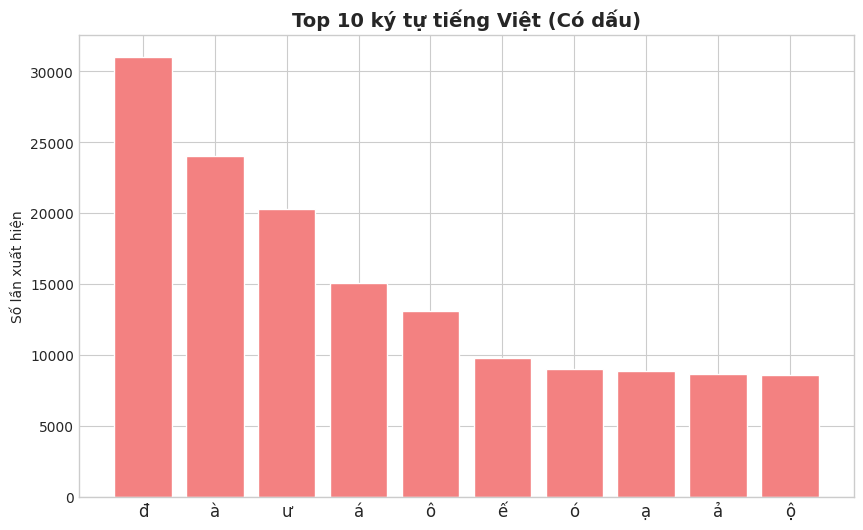

In [18]:
plt.figure(figsize=(10, 6))
if vn_only_counter:
    top_10_vn = vn_only_counter.most_common(10)
    vn_chars_list = [c[0] for c in top_10_vn]
    vn_counts = [c[1] for c in top_10_vn]

    plt.bar(vn_chars_list, vn_counts, color='#F38181')
    plt.title('Top 10 ký tự tiếng Việt (Có dấu)', fontsize=14, fontweight='bold')
    plt.ylabel('Số lần xuất hiện')
    plt.xticks(fontsize=12)
plt.show()

Nhận xét: 

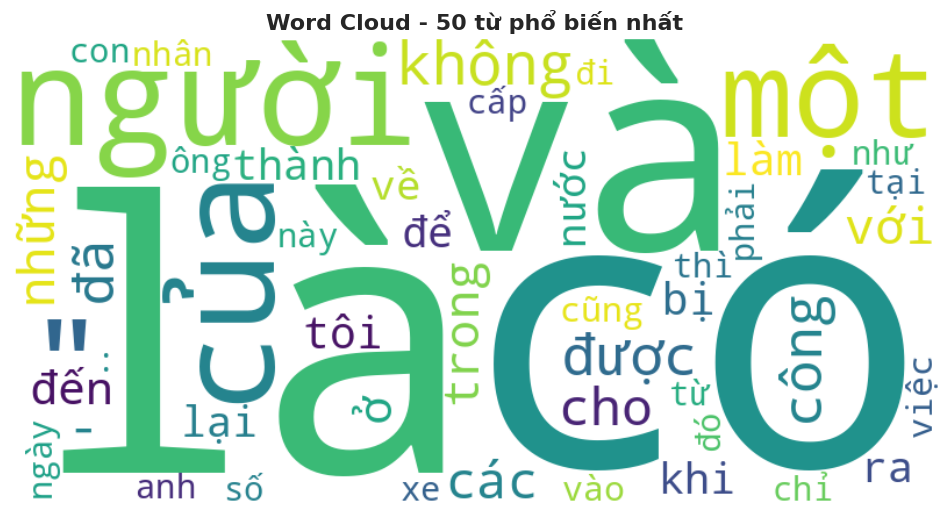

In [ ]:

plt.figure(figsize=(12, 8))
try:
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          max_words=50).generate_from_frequencies(dict(all_words_counter.most_common(50)))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud - 50 từ phổ biến nhất', fontsize=16, fontweight='bold')
except ImportError:
    plt.text(0.5, 0.5, 'Vui lòng cài đặt thư viện: pip install wordcloud', ha='center', va='center')
plt.show()

Nhận xét:

#### 2.5.5 [Tên mục]

Note: 
- Mô tả cell bên dưới
- Sửa lại cách hiển thị kết quả (đang bị đè lên nhau)
-

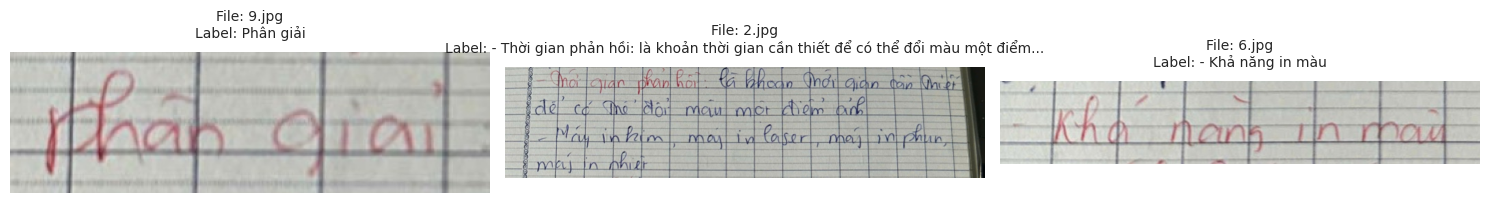

In [ ]:
# Đường dẫn
DATA_DIR = Path('/content/drive/MyDrive/IntroToML - OCR/tcuong/1')  
LABEL_FILE = DATA_DIR / 'label.json'

# Tải file label.json
with open(LABEL_FILE, 'r', encoding='utf-8') as f:
    labels_dict = json.load(f)

df = pd.DataFrame([
    {'image_file': k, 'label': v}
    for k, v in labels_dict.items()
])

def display_samples(df, n_samples=9, random_seed=42):
    # Đảm bảo cấu hình font hỗ trợ tiếng Việt
    mpl.rcParams['font.family'] = 'DejaVu Sans'

    np.random.seed(random_seed)
    samples = df.sample(n=min(n_samples, len(df)))

    n_cols = 3
    n_rows = (len(samples) + n_cols - 1) // n_cols

    # Tăng figsize một chút để tiêu đề tiếng Việt không bị chồng chéo
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows))

    # Xử lý trường hợp chỉ có 1 sample
    if n_samples == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, (_, row) in enumerate(samples.iterrows()):
        img_path = DATA_DIR / row['image_file']

        try:
            img = Image.open(img_path)
            axes[idx].imshow(img)

            # Xử lý nhãn tiếng Việt
            label = str(row['label'])
            if len(label) > 80:
                label = label[:77] + '...'

            # Sử dụng tham số wrap=True và điều chỉnh fontsize
            # Thêm tiêu đề với font DejaVu đã cài đặt
            axes[idx].set_title(f"File: {row['image_file']}\nLabel: {label}",
                                fontsize=10,
                                fontweight='normal',
                                pad=10,
                                loc='center')
            axes[idx].axis('off')

        except Exception as e:
            axes[idx].text(0.5, 0.5, f"Lỗi tải file:\n{row['image_file']}",
                          ha='center', va='center', fontsize=10, color='red')
            axes[idx].axis('off')

    # Ẩn các ô trống nếu số lượng mẫu không chia hết cho n_cols
    for i in range(idx + 1, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Gọi hàm
display_samples(df, n_samples=3)

### 2.6 [Tên mục]

Note:
- Mô tả cell bên dưới
- Tao đang thấy cái cell này nó như kiểu tổng hợp lại của mấy cell ở mục 2.4 đúng hong? -> Có gì nói cho t nghe sự khác biệt nha -> sau đó đưa cái cell này lên mục 2.4 ở vị trí nào đó phù hợp


In [ ]:
# Cấu hình
DRIVE_OCR = Path('/content/drive/MyDrive/IntroToML - OCR')
LOCAL_DATA = Path('/content/local_data')
OUTPUT_DIR = DRIVE_OCR / 'Data'

TARGET_TRAIN = 1000                 # Tổng số ảnh mục tiêu cho tập huấn luyện
IMAGES_PER_SUBFOLDER = 50           # Quy định số lượng ảnh trong mỗi thư mục con train
RANDOM_SEED = 42

# Danh sách nguồn dữ liệu nhóm
GROUP_DATA_SOURCES = [
    (DRIVE_OCR / 'tcuong', True),
    (DRIVE_OCR / 'qphuc', False),
    (DRIVE_OCR / 'tphat', False),
    (DRIVE_OCR / 'dkhoa', False),
    (DRIVE_OCR / 'hnhan', False),
]

# Định nghĩa các nguồn UIT
UIT_SOURCE_WORD = LOCAL_DATA / 'UIT_HWDB_word' / 'train_data'
UIT_SOURCE_LINE = LOCAL_DATA / 'UIT_HWDB_line' / 'train_data'
UIT_SOURCE_PARA = LOCAL_DATA / 'UIT_HWDB_paragraph' / 'train_data'

random.seed(RANDOM_SEED)

In [ ]:
# CÁC HÀM HỖ TRỢ XỬ LÝ
def collect_from_folder(folder_path):
    label_file = folder_path / 'label.json'
    if not label_file.exists():
        return []
    try:
        with open(label_file, 'r', encoding='utf-8') as f:
            content = f.read()
        content = re.sub(r',\s*}', '}', content)
        content = re.sub(r',\s*]', ']', content)
        labels = json.loads(content)
    except json.JSONDecodeError as e:
        print(f"Lỗi: Không thể giải mã JSON tại {folder_path}. Chi tiết: {e}")
        return []
    samples = []
    for img_name, label_text in labels.items():
        img_path = folder_path / img_name
        if img_path.exists():
            samples.append((img_path, label_text))
    return samples

def collect_group_data(sources):
    all_samples = []
    for folder_path, has_subfolders in sources:
        if not folder_path.exists(): continue
        if has_subfolders:
            for subfolder in sorted(folder_path.iterdir()):
                if subfolder.is_dir():
                    all_samples.extend(collect_from_folder(subfolder))
        else:
            all_samples.extend(collect_from_folder(folder_path))
    return all_samples

def collect_uit_by_type(source_path):
    samples = []
    if source_path.exists():
        for subfolder in sorted(source_path.iterdir()):
            if subfolder.is_dir():
                samples.extend(collect_from_folder(subfolder))
    return samples

def save_train_subfolders(samples, train_dir, per_folder):
    train_dir = Path(train_dir)
    train_dir.mkdir(parents=True, exist_ok=True)
    total_saved = 0
    folder_idx = 1
    for start in range(0, len(samples), per_folder):
        chunk = samples[start:start + per_folder]
        subfolder = train_dir / str(folder_idx)
        subfolder.mkdir(parents=True, exist_ok=True)
        labels = {}
        for idx, (img_path, label_text) in enumerate(chunk, 1):
            ext = img_path.suffix.lower()
            new_name = f"{idx}{ext}"
            shutil.copy2(str(img_path), str(subfolder / new_name))
            labels[new_name] = label_text
        with open(subfolder / 'label.json', 'w', encoding='utf-8') as f:
            json.dump(labels, f, ensure_ascii=False, indent=2)
        total_saved += len(chunk)
        folder_idx += 1
    return total_saved

def save_test_flat(samples, output_folder):
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)
    labels = {}
    for idx, (img_path, label_text) in enumerate(samples, 1):
        ext = img_path.suffix.lower()
        new_name = f"{idx}{ext}"
        shutil.copy2(str(img_path), str(output_folder / new_name))
        labels[new_name] = label_text
    with open(output_folder / 'label.json', 'w', encoding='utf-8') as f:
        json.dump(labels, f, ensure_ascii=False, indent=2)

# Bước 1: Thu thập dữ liệu nhóm
print("BƯỚC 1: TỔNG HỢP DỮ LIỆU NHÓM TỰ THU THẬP (MANUAL)")
print("-" * 60)
group_samples = collect_group_data(GROUP_DATA_SOURCES)
print(f"    Tổng số dữ liệu Manual thu thập được: {len(group_samples)}")

# Bước 2: Trích xuất dữ liệu UIT theo tỉ lệ
print("BƯỚC 2: TRÍCH XUẤT DỮ LIỆU TỪ BỘ UIT THEO TỈ LỆ")
uit_word_all = collect_uit_by_type(UIT_SOURCE_WORD)
uit_line_all = collect_uit_by_type(UIT_SOURCE_LINE)
uit_para_all = collect_uit_by_type(UIT_SOURCE_PARA)

# Xáo trộn ngẫu nhiên từng danh sách
random.shuffle(uit_word_all)
random.shuffle(uit_line_all)
random.shuffle(uit_para_all)

# Lấy 5 mẫu cho mỗi loại để đưa vào tập Test
uit_test = uit_word_all[:5] + uit_line_all[:5] + uit_para_all[:5]

# Phần còn lại sẽ được sử dụng để bổ sung cho tập Train
uit_for_train = uit_word_all[5:] + uit_line_all[5:] + uit_para_all[5:]

print(f"    Thống kê mẫu UIT:")
print(f"    + Loại chữ (word): {len(uit_word_all)} mẫu")
print(f"    + Loại câu (line): {len(uit_line_all)} mẫu")
print(f"    + Loại đoạn (paragraph): {len(uit_para_all)} mẫu")
print(f"    Đã trích xuất 15 mẫu (5 chữ + 5 câu + 5 đoạn) cho tập Test.")

# Bước 3: Xây dựng tập Train
print("BƯỚC 3: XÂY DỰNG TẬP DỮ LIỆU HUÂN LUYỆN (TRAIN)")
train_samples = list(group_samples)
needed_from_uit = max(0, TARGET_TRAIN - len(train_samples))

if needed_from_uit > 0:
    # Trộn lại danh sách UIT còn lại để lấy ngẫu nhiên các loại cho tập train
    random.shuffle(uit_for_train)
    train_samples.extend(uit_for_train[:needed_from_uit])
    print(f"    Bổ sung: Đã lấy thêm {needed_from_uit} mẫu từ UIT để đủ 1000 ảnh.")

# Xáo trộn toàn bộ tập train lần cuối
random.shuffle(train_samples)

print(f"    Cấu trúc tập Train: {len(group_samples)} ảnh nhóm + {needed_from_uit} ảnh UIT.")
print(f"    Cấu trúc tập Test: 15 mẫu")

# Bước 4: Lưu trữ dữ liệu trên Google Drive
print("BƯỚC 4: KHỞI TẠO CẤU TRÚC THƯ MỤC DỮ LIỆU TRÊN DRIVE")

if OUTPUT_DIR.exists():
    shutil.rmtree(str(OUTPUT_DIR))

save_train_subfolders(train_samples, OUTPUT_DIR / 'train', IMAGES_PER_SUBFOLDER)
save_test_flat(uit_test, OUTPUT_DIR / 'test')

print("TIẾN TRÌNH HOÀN TẤT")
print(f"    Vị trí lưu trữ: {OUTPUT_DIR}")
print(f"    Tổng số lượng ảnh Train: {len(train_samples)}")
print(f"    Tổng số lượng ảnh Test: {len(uit_test)}")

------------------------------------------------------------
BƯỚC 1: TỔNG HỢP DỮ LIỆU NHÓM TỰ THU THẬP (MANUAL)
------------------------------------------------------------
Tổng số dữ liệu Manual thu thập được: 494

------------------------------------------------------------
BƯỚC 2: TRÍCH XUẤT DỮ LIỆU TỪ BỘ UIT THEO TỈ LỆ
------------------------------------------------------------
Thống kê mẫu UIT:
  + Loại chữ (word): 107602 mẫu
  + Loại câu (line): 7027 mẫu
  + Loại đoạn (paragraph): 1113 mẫu
Đã trích xuất 15 mẫu (5 chữ + 5 câu + 5 đoạn) cho tập Test.

------------------------------------------------------------
BƯỚC 3: XÂY DỰNG TẬP DỮ LIỆU HUÂN LUYỆN (TRAIN)
------------------------------------------------------------
Bổ sung: Đã lấy thêm 506 mẫu từ UIT để đủ 1000 ảnh.
Cấu trúc tập Train: 494 ảnh nhóm + 506 ảnh UIT.
Cấu trúc tập Test: 15 mẫu

------------------------------------------------------------
BƯỚC 4: KHỞI TẠO CẤU TRÚC THƯ MỤC DỮ LIỆU TRÊN DRIVE
--------------------------